In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## 1. Load the dataset

df = pd.read_csv('./data/airbnb_hw.csv', low_memory = False)

print(df.shape)
print(df.head())

(30478, 13)
    Host Id Host Since                                Name Neighbourhood   \
0   5162530        NaN     1 Bedroom in Prime Williamsburg       Brooklyn   
1  33134899        NaN     Sunny, Private room in Bushwick       Brooklyn   
2  39608626        NaN                Sunny Room in Harlem      Manhattan   
3       500  6/26/2008  Gorgeous 1 BR with Private Balcony      Manhattan   
4       500  6/26/2008            Trendy Times Square Loft      Manhattan   

  Property Type  Review Scores Rating (bin)        Room Type  Zipcode  Beds  \
0     Apartment                         NaN  Entire home/apt  11249.0   1.0   
1     Apartment                         NaN     Private room  11206.0   1.0   
2     Apartment                         NaN     Private room  10032.0   1.0   
3     Apartment                         NaN  Entire home/apt  10024.0   3.0   
4     Apartment                        95.0     Private room  10036.0   3.0   

   Number of Records  Number Of Reviews Price  Rev

In [3]:
## 2. Schema

df.columns

Index(['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type',
       'Review Scores Rating (bin)', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price',
       'Review Scores Rating'],
      dtype='str')

In [4]:
df.dtypes

Host Id                         int64
Host Since                        str
Name                              str
Neighbourhood                     str
Property Type                     str
Review Scores Rating (bin)    float64
Room Type                         str
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                             str
Review Scores Rating          float64
dtype: object

<Axes: >

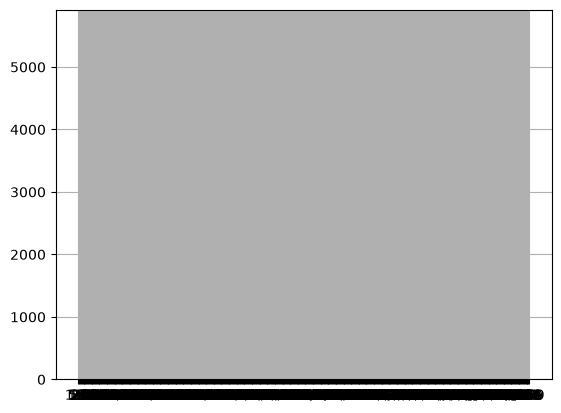

In [5]:
df["Price"]

df["Price"].hist(bins = 50)

In [6]:
## Cleaning

df["Review Scores Rating"].isna().sum()

np.int64(8323)

In [7]:
## Cleaning price

df["Price"] = pd.to_numeric(df["Price"].str.replace(',', ''), errors="coerce")



<Axes: >

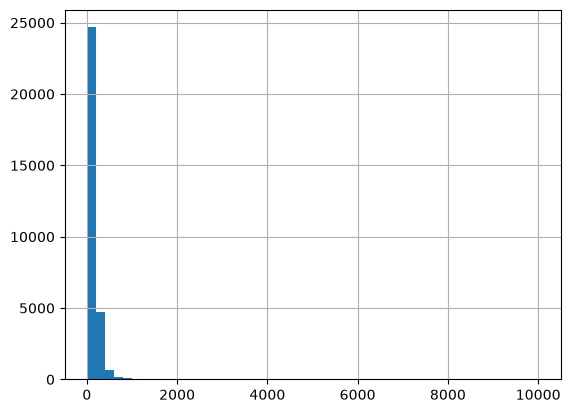

In [8]:
df["Price"].hist(bins = 50)

<Axes: >

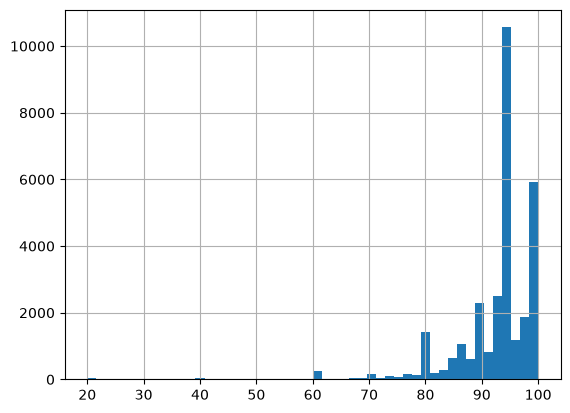

In [9]:
## 4. Missing values and imputation

df["Review Scores Rating"].isna().sum()

# 1. Missing Value Dummy
df['review_na'] = df['Review Scores Rating'].isna()

# 2. Imputation
imputation_value = df['Review Scores Rating'].median()

df['review'] = df["Review Scores Rating"].fillna(imputation_value)


df['review'].hist(bins = 50)

<Axes: >

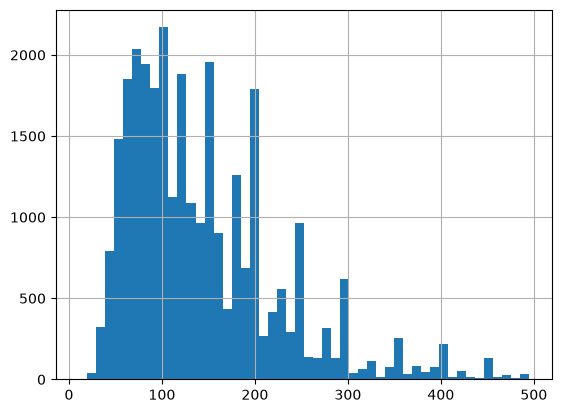

In [10]:
## 5. Filtering

# Row filter on property type:
keep = ['Apartment', 'House', 'Other', 'Bed & Breakfast', 'Loft', 'Condominium', 'Townhouse']

row_condition = df['Property Type'].isin(keep)

df_legit_prop = df[row_condition]

row_condition = df['Price'] < 499

df_reasonable_prices = df[row_condition]

df_reasonable_prices['Price'].hist(bins = 50)

In [11]:
# Column filter

cols = ['Host Id', 'Host Since', 'Name', 'Neighbourhood ', 'Property Type', 'Room Type', 'Zipcode', 'Beds',
       'Number of Records', 'Number Of Reviews', 'Price', 'review_na', 'review']

df_column_filtered = df_reasonable_prices[cols]

In [12]:
df_column_filtered.shape

(29688, 13)

In [13]:
## 6. Save cleaned dataframe

df_column_filtered.to_csv('./data/airbnb_cleaned.csv', index = False)